# WhyWatt — Rate Switch Review (Phase 6 WS1 · §1c)

**What Phase 7 will change when the default rate switch is flipped.**

Phase 6 adds the projection-backed rate models (`whywatt_*`, `eia_*`, `cec_*`, `e3_gas`) as
**non-default** options. This notebook quantifies the difference between **today's formula path**
and the **projection curves**, per fuel and per scenario, so the Phase 7 default-switch decision
has a number behind it.

- **Bundle:** `data/rates/projection/whywatt_rate_projection.json` (read as data via the core
  `ProjectedRateSource` — this notebook does **not** import the offline `rate_projection` package).
- **Formula baseline:** the CLAUDE.md *moderate* formula — electricity **+7%/yr**, gas **+8%/yr**,
  anchored to the PG&E tariff ($0.386/kWh, $2.08/therm). Electricity shares that base with the
  curves, so it isolates the escalation shape. **Gas does not since the 2026-09-24 gas-rate base
  review:** the $2.08 "G-1" figure was PG&E's CARE baseline charge, and the gas curves now start at
  the CEC delivered price ($2.649, 2025 nominal), so gas levels here include a ~27 % base
  difference. (Since Phase 7 §4.1 the simulator uses only the curves' *shape*, on the home's own
  current rate — see `docs/GasRateBase_Review_Plan.md`.)
- **Scope:** retail levels only (NEM export + social overlay stay on legacy — locked decision).


In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

from projected_rate_source import ProjectedRateSource, PROJECTION_LABELS
from model import HESModel
from home_config import HomeConfig

BASE = {"electricity": 0.386, "gas": 2.08}   # formula base: PG&E E-1 / legacy 'G-1' (CARE baseline) file
FORMULA_CAGR = {"electricity": 0.07, "gas": 0.08}   # CLAUDE.md 'moderate' formula
YEARS = list(range(2025, 2050))              # 25-year horizon (bundle 2025-2050)
N = len(YEARS)

def formula_series(fuel):
    return np.array([BASE[fuel] * (1 + FORMULA_CAGR[fuel]) ** i for i in range(N)])

def projection_series(model_key, fuel):
    src = ProjectedRateSource(model_key, fuel)
    return np.array([src.get_rate(fuel, y, 1) for y in YEARS])

print("horizon:", YEARS[0], "->", YEARS[-1], f"({N} yrs)")


horizon: 2025 -> 2049 (25 yrs)


## 1 · Retail rate trajectories — formula vs projection

Left = electricity, right = gas. The dashed black line is today's formula path; the coloured
lines are the three WhyWatt scenarios plus the CEC reference (CEC 2025 IEPR for electricity,
CEC 2025 BAU-invest for gas).

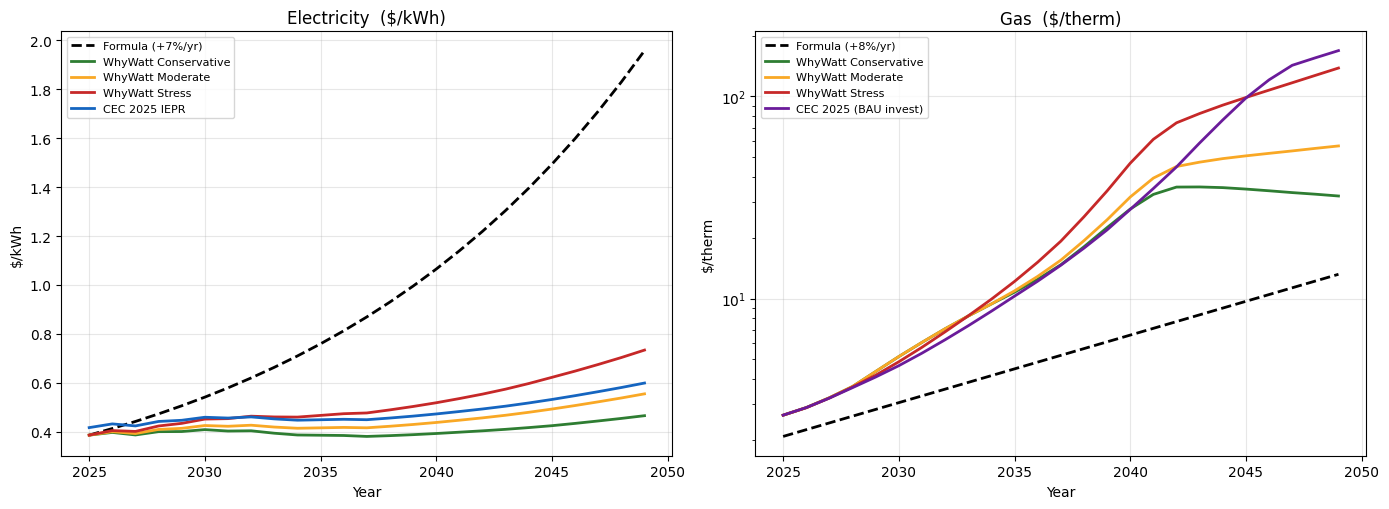

In [2]:
ELEC_MODELS = ["whywatt_conservative", "whywatt_moderate", "whywatt_stress", "cec_iepr"]
GAS_MODELS  = ["whywatt_conservative", "whywatt_moderate", "whywatt_stress", "cec_bau"]
COLORS = {"whywatt_conservative": "#2E7D32", "whywatt_moderate": "#F9A825",
          "whywatt_stress": "#C62828", "cec_iepr": "#1565C0", "cec_bau": "#6A1B9A"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
for ax, fuel, unit, models in [(axes[0], "electricity", "$/kWh", ELEC_MODELS),
                               (axes[1], "gas", "$/therm", GAS_MODELS)]:
    ax.plot(YEARS, formula_series(fuel), "k--", lw=2, label="Formula (+%d%%/yr)" %
            (FORMULA_CAGR[fuel] * 100))
    for mk in models:
        ax.plot(YEARS, projection_series(mk, fuel), lw=2,
                color=COLORS[mk], label=PROJECTION_LABELS[mk])
    ax.set_title(f"{fuel.title()}  ({unit})"); ax.set_xlabel("Year"); ax.set_ylabel(unit)
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
axes[1].set_yscale("log")   # gas spiral spans two orders of magnitude
plt.tight_layout(); plt.show()


## 2 · Level & implied-CAGR table

For each model, the 2025 base, the 2049 endpoint, and the implied constant CAGR that would
connect them — next to the formula path. This is the "escalation shape" difference in numbers.

In [3]:
def implied_cagr(series):
    return (series[-1] / series[0]) ** (1 / (N - 1)) - 1

def row(label, s):
    return f"{label:<26} {s[0]:>9.3f} {s[-1]:>11.3f} {implied_cagr(s)*100:>10.1f}%"

for fuel, models in [("electricity", ELEC_MODELS), ("gas", GAS_MODELS)]:
    print(f"\n=== {fuel.upper()} ({'$/kWh' if fuel=='electricity' else '$/therm'}) ===")
    print(f"{'model':<26} {'2025':>9} {'2049':>11} {'impliedCAGR':>11}")
    print(row("Formula (moderate)", formula_series(fuel)))
    for mk in models:
        print(row(PROJECTION_LABELS[mk], projection_series(mk, fuel)))



=== ELECTRICITY ($/kWh) ===


model                           2025        2049 impliedCAGR
Formula (moderate)             0.386       1.958        7.0%
WhyWatt Conservative           0.386       0.465        0.8%
WhyWatt Moderate               0.386       0.555        1.5%
WhyWatt Stress                 0.386       0.734        2.7%
CEC 2025 IEPR                  0.417       0.599        1.5%

=== GAS ($/therm) ===
model                           2025        2049 impliedCAGR
Formula (moderate)             2.080      13.190        8.0%
WhyWatt Conservative           2.649      32.180       11.0%
WhyWatt Moderate               2.649      56.916       13.6%
WhyWatt Stress                 2.649     138.261       17.9%
CEC 2025 (BAU invest)          2.651     168.597       18.9%


## 3 · Headline bill impact — do-nothing gas cost

We take the **same** do-nothing (all-gas) home's annual gas quantity from a default sim run and
re-price it under the formula path vs each projection scenario. Same energy, different prices —
so this isolates the rate effect. This is the number that moves most when the switch is flipped:
the gas death-spiral scenarios reprice a do-nothing home's gas bill dramatically upward.

In [4]:
m = HESModel(home_config=HomeConfig(), n_years=N, sim_start_year=2025)
m.run_all()
gas_therms = np.array(m.baseline_home.gas_therms_history[:N])   # do-nothing annual therms
print("do-nothing gas quantity (therms/yr):", round(float(gas_therms[0])), "(flat)")

def cum_gas_cost(series):
    return float(np.sum(gas_therms * series))

formula_cost = cum_gas_cost(formula_series("gas"))
print(f"\n25-yr do-nothing GAS cost (undiscounted, nominal):")
print(f"  {'Formula (+8%/yr)':<26} ${formula_cost:>12,.0f}   (baseline)")
for mk in GAS_MODELS:
    c = cum_gas_cost(projection_series(mk, "gas"))
    print(f"  {PROJECTION_LABELS[mk]:<26} ${c:>12,.0f}   ({c/formula_cost:>5.2f}x formula)")


do-nothing gas quantity (therms/yr): 593 (flat)

25-yr do-nothing GAS cost (undiscounted, nominal):
  Formula (+8%/yr)           $      90,207   (baseline)
  WhyWatt Conservative       $     276,338   ( 3.06x formula)
  WhyWatt Moderate           $     366,625   ( 4.06x formula)
  WhyWatt Stress             $     653,760   ( 7.25x formula)
  CEC 2025 (BAU invest)      $     625,284   ( 6.93x formula)


## 4 · What Phase 7 will change (summary)

- **Electricity:** today's formula escalates a flat **+7%/yr**; the WhyWatt/CEC projection curves
  are far gentler (roughly real-flat, ~+2%/yr nominal). **Switching *lowers* projected electricity
  cost** — the journey's electric bill looks better under projection.
- **Gas:** today's formula is a flat **+8%/yr**; the projection reshapes gas into a **spiral**
  (WhyWatt Stress and especially **CEC 2025 BAU-invest**, the labelled upper-bound). **Switching
  raises the do-nothing gas cost materially**, strengthening the electrification case.
- **Net:** flipping the default in Phase 7 will *widen* the do-nothing-vs-journey gap. The tables
  above are the sign-off numbers; re-baseline the golden at that point.

> **Caveat:** CEC 2025 BAU-invest is an explicit upper-bound / most-extreme published case, not a
> central forecast. Present it as a bound, alongside WhyWatt Moderate as the central story.